<a href="https://colab.research.google.com/github/yamanjoshi41/Business-Strategy-Game-Simulation/blob/main/Industry_Revenue_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

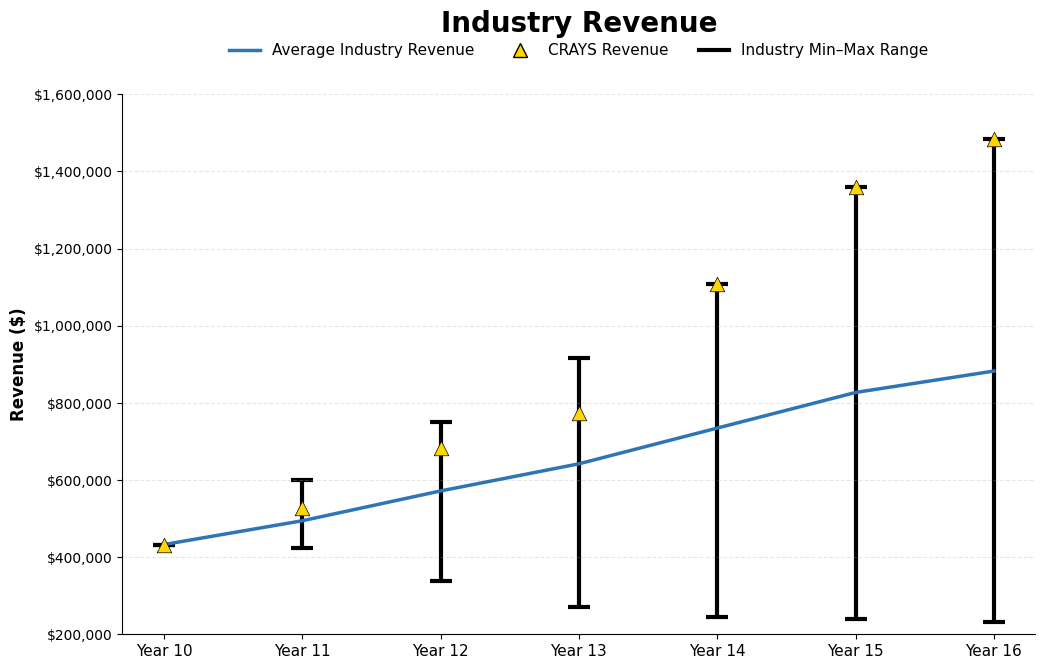

In [1]:
"""
Industry Revenue chart:
- Blue line  = Average Industry Revenue
- Gold triangles = CRAYS Revenue
- Black error bars = Industry revenue range (min/max) around the average
"""

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# ---- 1. Data ----
years = ["Year 10", "Year 11", "Year 12", "Year 13", "Year 14", "Year 15", "Year 16"]

# Company C (CRAYS Athletics) Net Sales Revenues Total
crays_revenue = [432646, 526645, 681942, 774898, 1109359, 1360881, 1483316]

# Minimum Net Sales Revenues across all companies in Industry 12
industry_min = [432646, 423289, 336951, 271906, 245595, 240756, 231316]

# Maximum Net Sales Revenues across all companies in Industry 12
industry_max = [432646, 601083, 749656, 917540, 1109359, 1360881, 1483316]

# Official Industry Average Net Sales Revenues
avg_industry_revenue = [432646, 494301, 571616, 641931, 734600, 826928, 882439]

x = range(len(years))

# Error bar distances
lower_err = [avg - lo for avg, lo in zip(avg_industry_revenue, industry_min)]
upper_err = [hi - avg for hi, avg in zip(industry_max, avg_industry_revenue)]

# ---- 2. Plot ----
fig, ax = plt.subplots(figsize=(11, 7.5))

# Industry Range
ax.errorbar(
    x,
    avg_industry_revenue,
    yerr=[lower_err, upper_err],
    fmt="none",
    ecolor="black",
    elinewidth=3,
    capsize=8,
    capthick=3,
    zorder=1
)

# Industry Average
ax.plot(
    x,
    avg_industry_revenue,
    color="#2E75B6",
    linewidth=2.5,
    label="Average Industry Revenue",
    zorder=2
)

# CRAYS Revenue
ax.scatter(
    x,
    crays_revenue,
    color="#FFD700",
    marker="^",
    s=110,
    edgecolors="black",
    linewidths=0.5,
    label="CRAYS Revenue",
    zorder=3
)

# ---- 3. Formatting ----
ax.set_title(
    "Industry Revenue",
    fontsize=20,
    fontweight="bold",
    pad=45
)

ax.set_ylabel(
    "Revenue ($)",
    fontsize=12,
    fontweight="bold"
)

ax.set_xticks(list(x))
ax.set_xticklabels(years, fontsize=11)

# ==========================
# UPDATED SCALE ONLY
# ==========================
ax.set_ylim(200000, 1600000)

# Tick every $200,000
ax.yaxis.set_major_locator(mticker.MultipleLocator(200000))

# Display as normal dollars
ax.yaxis.set_major_formatter(
    mticker.StrMethodFormatter('${x:,.0f}')
)

# ==========================

ax.grid(axis="y", linestyle="--", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(
    handles=[
        Line2D([0], [0],
               color="#2E75B6",
               linewidth=2.5,
               label="Average Industry Revenue"),

        Line2D([0], [0],
               marker="^",
               color="w",
               markerfacecolor="#FFD700",
               markeredgecolor="black",
               markersize=10,
               label="CRAYS Revenue"),

        Line2D([0], [0],
               color="black",
               linewidth=3,
               label="Industry Min–Max Range"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=3,
    frameon=False,
    fontsize=11
)

plt.subplots_adjust(
    top=0.82,
    bottom=0.10,
    left=0.12,
    right=0.95
)

plt.savefig(
    "industry_revenue_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()